In [1]:
import pandas as pd
import torch.nn as nn
from sklearn.datasets import fetch_california_housing

## 1. Data Preprocessing

In [2]:
data = fetch_california_housing()

In [3]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)

In [4]:
df['target'] = data.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

## 2. Train-test-split

In [7]:
X = data.data
y = data.target

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Model Architecture

In [10]:
class ANNRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            
            ## 1st hidden layer
            nn.Linear(8,64),
            nn.ReLU(),
            ## 2nd hidden layer
            nn.Linear(64,32),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.model(x)

## 4. Model Training

In [11]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [13]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [14]:
import torch.optim as optim

model = ANNRegression()
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters())

In [15]:
best_training_loss = float('inf')
best_validation_loss = float('inf')
epochs = 100
best_epoch = 0

training_losses = []
validation_losses = []

for epoch in range(epochs):

    model.train()
    running_training_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_training_loss += loss.item()

    epoch_running_loss = running_training_loss / len(train_loader)
    training_losses.append(epoch_running_loss)

    if epoch_running_loss < best_training_loss:
        best_training_loss = epoch_running_loss
        best_epoch_training = epoch
        torch.save(model.state_dict(), 'best_model.pt')

    model.eval()
    validation_running_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:

            outputs = model(xb)
            loss = criterion(outputs, yb)
            validation_running_loss += loss.item()

        epoch_running_loss = validation_running_loss / len(xb)

        if epoch_running_loss < best_validation_loss:
            best_validation_loss = epoch_running_loss
            best_epoch_validation = epoch

        validation_losses.append(epoch_running_loss)

print(f"minimal loss of {best_validation_loss} was achieved at validation epoch : {best_epoch_validation+1}")
print(f"minimal loss of {best_training_loss} was achieved at training epoch : {best_epoch_training+1}")
    

minimal loss of 0.5333214839920402 was achieved at validation epoch : 98
minimal loss of 0.27080420216964196 was achieved at training epoch : 100


## 5. Training vs Validation loss plot

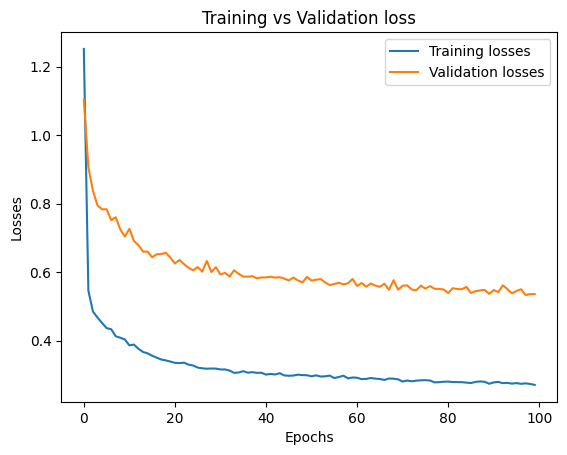

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    'Training losses' : training_losses,
    'Validation losses' : validation_losses
})

plt.plot(loss_df['Training losses'], label = 'Training losses')
plt.plot(loss_df['Validation losses'], label = 'Validation losses')

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Training vs Validation loss")

plt.legend()

## 6. Evaluating best model

In [17]:
model.load_state_dict(torch.load('best_model.pt'))

<All keys matched successfully>

In [18]:
model.eval()
with torch.no_grad():
    training_outputs = model(X_train_tensor)
    testing_outputs = model(X_test_tensor)

    training_mse_loss = criterion(training_outputs, y_train_tensor)
    testing_mse_loss = criterion(testing_outputs, y_test_tensor)

print("Training MSE:", training_mse_loss.item())
print("Testing MSE:", testing_mse_loss.item())


Training MSE: 0.24119099974632263
Testing MSE: 0.26415613293647766


In [19]:
from sklearn.metrics import r2_score, mean_squared_error

print(f'mse : {mean_squared_error(y_test, testing_outputs)}')
print(f'r^2 score : {r2_score(y_test, testing_outputs)}')

mse : 0.26415614638863816
r^2 score : 0.7984170203540251


## 7. Actual vs Predicted values plot

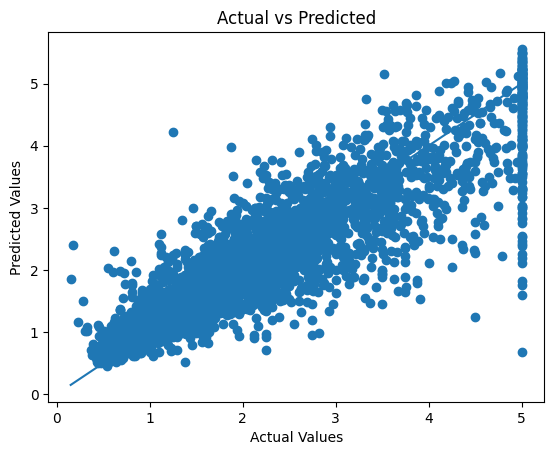

In [20]:
plt.figure()

plt.scatter(y_test, testing_outputs)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

#### mean squared error achieved for best model : 0.26415614638863816
#### r^2 score achieved for best model : 0.7984170203540251
